Make correlation matrix of neurons in explore, project h&e data onto it  
Inspired by plots and analyses in Elsayed et al. 2016 Reorganization between preparatory and movement population responses in motor cortex

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [2]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from behave_analysis.analyze.CCA.cca_utils import select_train_test_frames
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import homing_escape_boolean_vectors

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec
import os
import dill as pickle
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Necessary for 3D plotting
import seaborn as sns
import scipy
from scipy.stats import spearmanr
import polars as pl
%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]

In [5]:
e = 8

session_name = list(experiments_objects.keys())[e]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
mean_fr = np.nanmean(fcm, axis=0)
std_fr = np.nanstd(fcm, axis=0)
fcm_z = (fcm - mean_fr) / std_fr
assert len(video_df) == fcm.shape[0], "Number of frames in video dataframe does not match number of frames in frame-by-cluster matrix"
n_neurons = fcm.shape[1]

2026-04-02 19:00:43.024 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_11728\2071662057.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


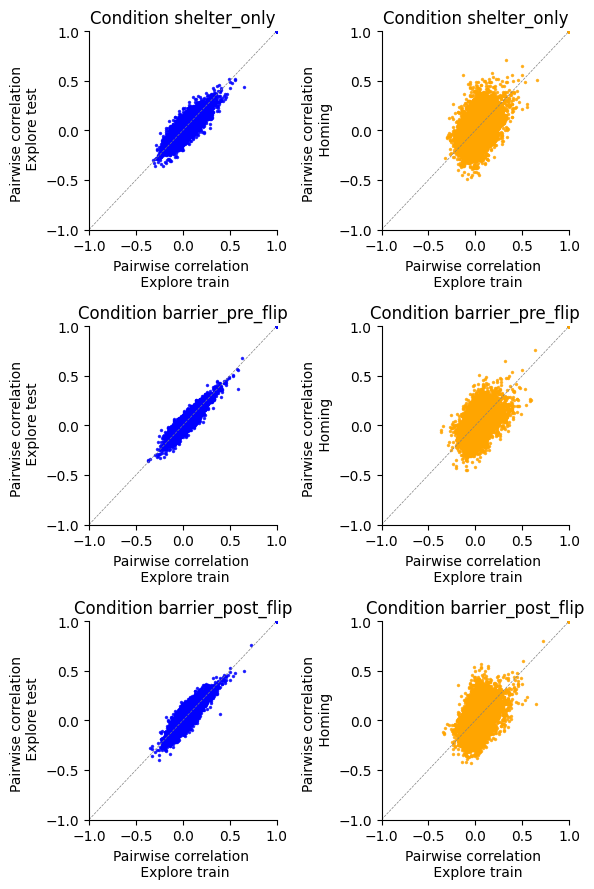

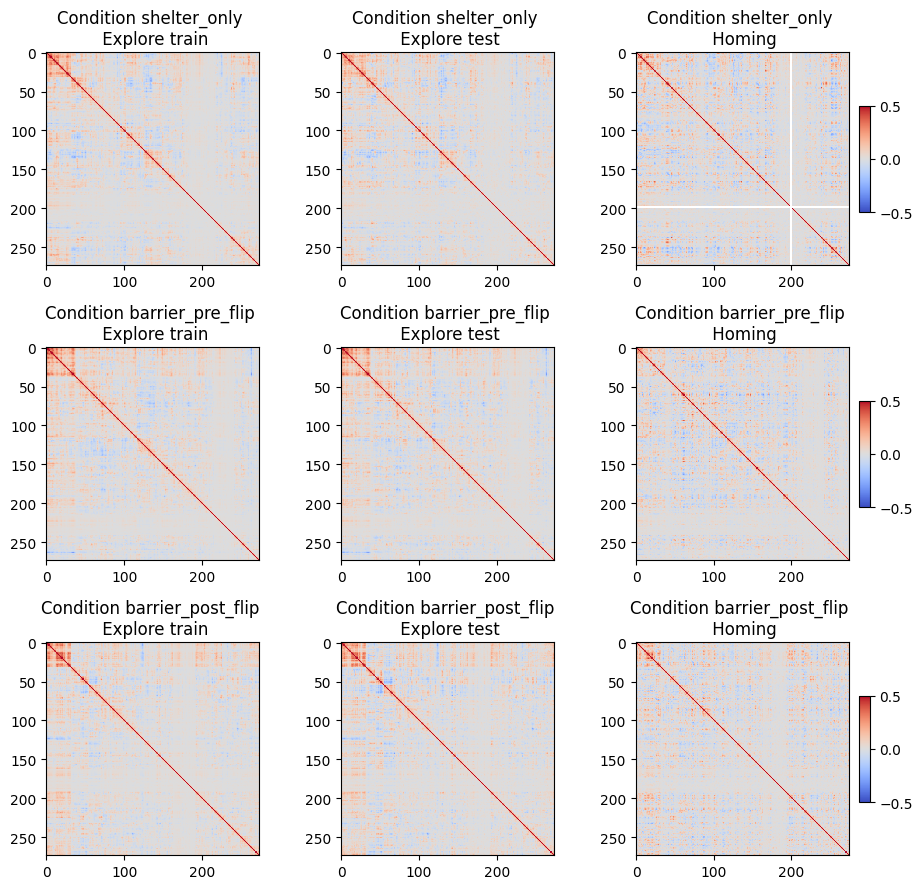

In [8]:
"""Compute pariwise correlation between neurons in exploration and homings, for each condition."""
fig1, axs = plt.subplots(3, 2, figsize=(6, 9))
fig2, axs2 = plt.subplots(3, 3, figsize=(9, 9))

for c in range(len(cond_list)):

    explore_train_idx, explore_test_idx, homing_indices = select_train_test_frames(video_df, cond_list[c], method = "balanced_bins_pos")
    A1 = fcm[explore_train_idx, :]
    A2 = fcm[explore_test_idx, :]
    B = fcm[homing_indices, :]

    A1_corr_matrix, _ = spearmanr(A1, axis = 0)
    A2_corr_matrix, _ = spearmanr(A2, axis = 0)
    B_corr_matrix, _ = spearmanr(B, axis = 0)

    for i in range(2):
        axs[c,i].plot([-1, 1], [-1, 1], color='gray', linestyle='--', linewidth=0.5)
        
    for n in range(n_neurons):
        axs[c, 0].scatter(A1_corr_matrix[n, :], A2_corr_matrix[n, :], color='blue', s = 2, alpha = 0.5)
        axs[c, 1].scatter(A1_corr_matrix[n, :], B_corr_matrix[n, :], color='orange', s = 2, alpha = 0.5)

    axs[c, 0].set_xlabel("Pairwise correlation \n Explore train")
    axs[c, 0].set_ylabel("Pairwise correlation \n Explore test")
    axs[c, 0].set_title(f"Condition {cond_list[c]}")
    axs[c, 0].set_xlim(-1, 1)
    axs[c, 0].set_ylim(-1, 1)
    axs[c, 0].spines['top'].set_visible(False)
    axs[c, 0].spines['right'].set_visible(False)
    axs[c, 1].set_xlabel("Pairwise correlation \n Explore train")
    axs[c, 1].set_ylabel("Pairwise correlation \n Homing")
    axs[c, 1].set_title(f"Condition {cond_list[c]}")
    axs[c, 1].set_xlim(-1, 1)
    axs[c, 1].set_ylim(-1, 1)
    axs[c, 1].spines['top'].set_visible(False)
    axs[c, 1].spines['right'].set_visible(False)

    # Plot the correlation matrices
    vmin, vmax = -0.5, 0.5
    # sort the A1 matrix
    dist = 1-A1_corr_matrix
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist, 0)
    res = scipy.cluster.hierarchy.linkage(scipy.spatial.distance.squareform(dist), method='ward')
    dendro = scipy.cluster.hierarchy.dendrogram(res, no_plot=True)
    idx = dendro['leaves']

    axs2[c, 0].imshow(A1_corr_matrix[idx, :][:, idx], vmin=vmin, vmax=vmax, cmap='coolwarm')
    axs2[c, 0].set_title(f"Condition {cond_list[c]} \n Explore train")

    axs2[c, 1].imshow(A2_corr_matrix[idx, :][:, idx], vmin=vmin, vmax=vmax, cmap='coolwarm')
    axs2[c, 1].set_title(f"Condition {cond_list[c]} \n Explore test")

    im3 = axs2[c, 2].imshow(B_corr_matrix[idx, :][:, idx], vmin=vmin, vmax=vmax, cmap='coolwarm')
    axs2[c, 2].set_title(f"Condition {cond_list[c]} \n Homing")
    cbar_ax = inset_axes(axs2[c, 2],
                        width="5%",  # width: 5% of parent_bbox width
                        height="50%",  # height: 50% of parent_bbox height
                        loc='right',
                        bbox_to_anchor=(0.1, 0., 1, 1),
                        bbox_transform=axs2[c, 2].transAxes,
                        borderpad=0)
    fig2.colorbar(im3, cax=cbar_ax)

fig1.tight_layout()
fig2.tight_layout()

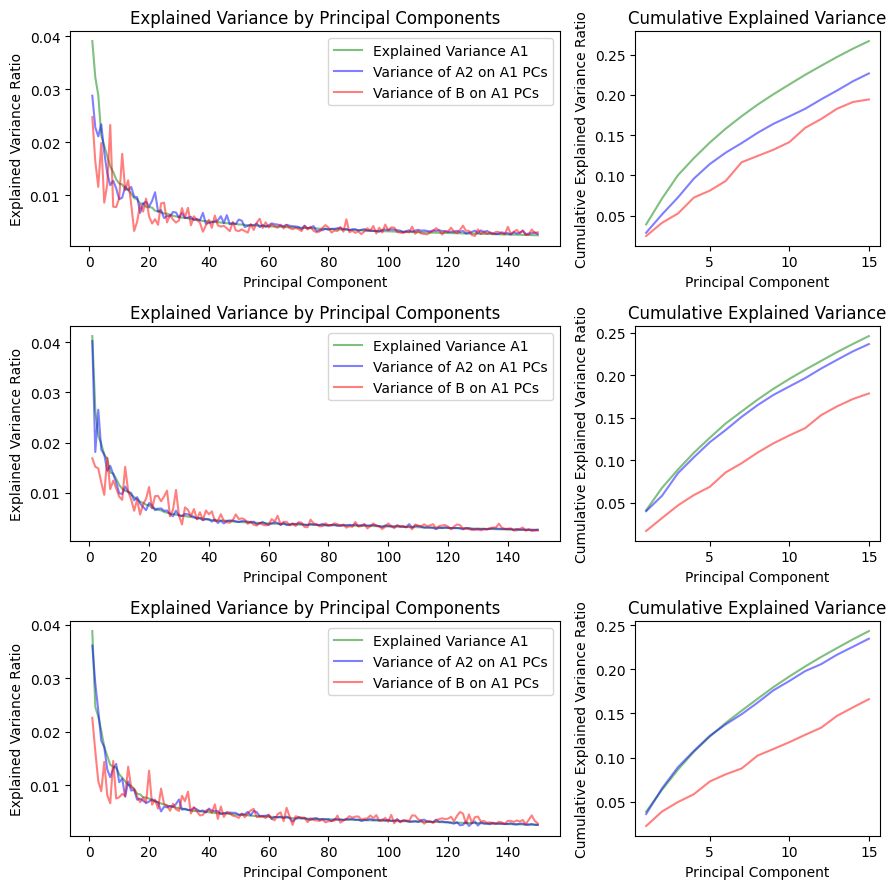

In [9]:
fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[2, 1])

for c in range(len(cond_list)):
        explore_train_idx, explore_test_idx, homing_indices = select_train_test_frames(video_df, cond_list[c], method = "balanced_bins_pos")
        A1_z = fcm_z[explore_train_idx, :]
        A2_z = fcm_z[explore_test_idx, :]
        B_z = fcm_z[homing_indices, :]

        # 3. Fit PCA on A1
        # We'll take the top 'k' components that explain, say, 80% of variance
        pca_a = PCA(n_components = 150)
        pca_a.fit(A1_z)
        V_a = pca_a.components_ # The eigenvectors (k, n_neurons)

        # 4. Project A2 and B onto A1's eigenvectors
        # This is essentially: (Data @ V_a.T)
        proj_A2 = pca_a.transform(A2_z)
        proj_B = pca_a.transform(B_z)
        xvals = np.arange(proj_A2.shape[1]) + 1
        
        ax_var = fig.add_subplot(gs[c, 0])
        ax_var.plot(xvals, pca_a.explained_variance_ratio_, color = 'green', label='Explained Variance A1', alpha = 0.5)
        var_per_dim_A2 = np.var(proj_A2, axis=0)
        var_per_dim_B = np.var(proj_B, axis=0)
        total_var_A2 = np.var(A2_z, axis=0).sum()
        total_var_B = np.var(B_z, axis=0).sum()
        ax_var.plot(xvals, var_per_dim_A2 / total_var_A2, color='blue', label='Variance of A2 on A1 PCs', alpha = 0.5)
        ax_var.plot(xvals, var_per_dim_B / total_var_B, color='red', label='Variance of B on A1 PCs', alpha = 0.5)
        ax_var.set_title("Explained Variance by Principal Components")
        ax_var.set_xlabel("Principal Component")
        ax_var.set_ylabel("Explained Variance Ratio")
        # ax_var.set_xscale('log')
        # ax_var.set_yscale('log')
        ax_var.legend()

        ax_cum = fig.add_subplot(gs[c, 1])
        ax_cum.plot(xvals[:15], np.cumsum(pca_a.explained_variance_ratio_[:15]), color = 'green', label='Cumulative Explained Variance A1', alpha = 0.5)
        ax_cum.plot(xvals[:15], np.cumsum(var_per_dim_A2[:15] / total_var_A2), color='blue', label='Cumulative Variance of A2 on A1 PCs', alpha = 0.5)
        ax_cum.plot(xvals[:15], np.cumsum(var_per_dim_B[:15] / total_var_B), color='red', label='Cumulative Variance of B on A1 PCs', alpha = 0.5)
        ax_cum.set_xlabel("Principal Component")
        ax_cum.set_ylabel("Cumulative Explained Variance Ratio")
        ax_cum.set_title("Cumulative Explained Variance")
plt.tight_layout()

2026-04-02 14:54:00.469 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-02 14:56:00.991 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-02 14:58:25.480 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-02 14:59:53.061 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-02 15:01:32.656 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-02 15:03:05.982 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-02

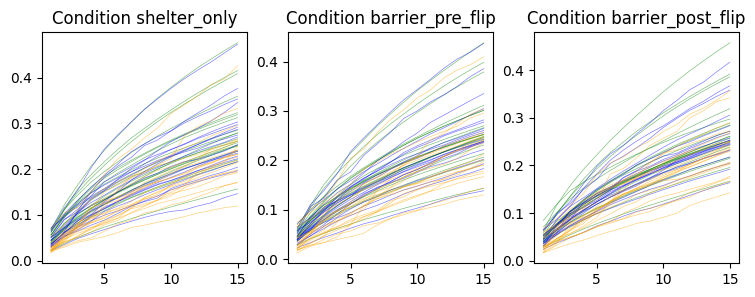

In [3]:
"""Look at neuron neuron correlation across sessions, for each condition."""
exp_train_cum_var_explained = np.full((len(experiments_objects), len(cond_list), 15), np.nan)
exp_test_cum_var_explained = np.full((len(experiments_objects), len(cond_list), 15), np.nan)
h_test_cum_var_explained = np.full((len(experiments_objects), len(cond_list), 15), np.nan)

for e in range(len(experiments_objects)):
    session_name = list(experiments_objects.keys())[e]
    exp = experiments_objects[session_name]
    session = Process(exp).load_session()
    video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
    if "homingPeriod" not in video_df.columns:
        homing_path = os.path.join(session.base_path, session.processed_path, "homings", "homings_obj.pkl")
        with open(homing_path, "rb") as f:
            homing_object = pickle.load(f)
        homing_period = homing_escape_boolean_vectors(homing_object, len(video_df))
        video_df = video_df.with_columns(pl.Series(name="homingPeriod", values=homing_period))
    if "EscapePeriod" not in video_df.columns:
        escape_path = os.path.join(session.base_path, session.processed_path, "escape_periods", "escapes_obj.pkl")
        with open(escape_path, "rb") as f:
            escape_object = pickle.load(f)
        escape_period = homing_escape_boolean_vectors(escape_object, len(video_df))
        video_df = video_df.with_columns(pl.Series(name="EscapePeriod", values=escape_period))
    fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
    mean_fr = np.nanmean(fcm, axis=0)
    std_fr = np.nanstd(fcm, axis=0)
    fcm_z = (fcm - mean_fr) / std_fr
    assert len(video_df) == fcm.shape[0], "Number of frames in video dataframe does not match number of frames in frame-by-cluster matrix"
    n_neurons = fcm.shape[1]

    for c, cond in enumerate(cond_list):
        explore_train_idx, explore_test_idx, homing_indices = select_train_test_frames(video_df, cond, method = "balanced_bins_pos")
        A1_z = fcm_z[explore_train_idx, :]
        A2_z = fcm_z[explore_test_idx, :]
        B_z = fcm_z[homing_indices, :]

        # 3. Fit PCA on A1
        # We'll take the top 'k' components that explain, say, 80% of variance
        pca_a = PCA()
        pca_a.fit(A1_z)

        # 4. Project A2 and B onto A1's eigenvectors
        # This is essentially: (Data @ V_a.T)
        proj_A2 = pca_a.transform(A2_z)
        proj_B = pca_a.transform(B_z)
        
        exp_train_cum_var_explained[e, c, :] = np.cumsum(pca_a.explained_variance_ratio_[:15])
        var_per_dim_A2 = np.var(proj_A2, axis=0)
        var_per_dim_B = np.var(proj_B, axis=0)
        total_var_A2 = np.var(A2_z, axis=0).sum()
        total_var_B = np.var(B_z, axis=0).sum()
        exp_test_cum_var_explained[e, c, :] = np.cumsum(var_per_dim_A2[:15] / total_var_A2)
        h_test_cum_var_explained[e, c, :] = np.cumsum(var_per_dim_B[:15] / total_var_B)

fig, axs = plt.subplots(1,3, figsize=(9,3))
for c in range(len(cond_list)):
    axs[c].plot(np.arange(1,16), exp_train_cum_var_explained[:,c,:].T, color='green', label='Cumulative Explained Variance A1', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), exp_test_cum_var_explained[:,c,:].T, color='blue', label='Cumulative Variance of A2 on A1 PCs', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), h_test_cum_var_explained[:,c,:].T, color='orange', label='Cumulative Variance of B on A1 PCs', alpha = 0.5, linewidth = 0.5)
    axs[c].set_title(f"Condition {cond_list[c]}") 


Text(0, 0.5, 'Cumulative Variance Ratio (Train/Test)')

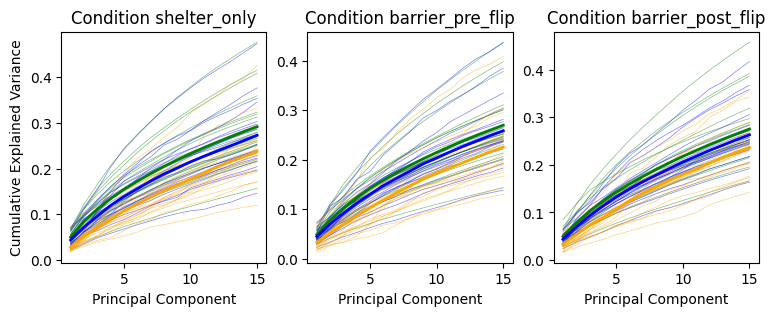

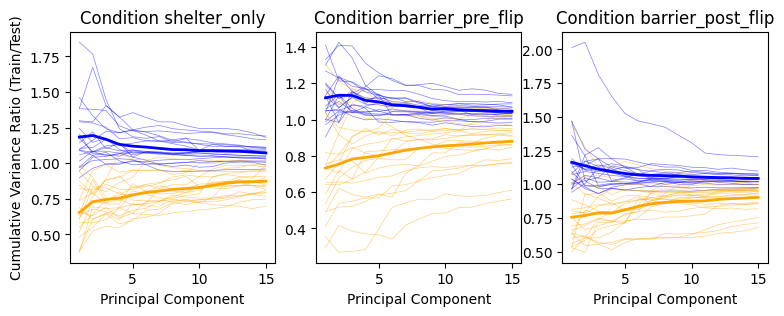

In [4]:

fig, axs = plt.subplots(1,3, figsize=(9,3))
for c in range(len(cond_list)):
    axs[c].plot(np.arange(1,16), exp_train_cum_var_explained[:,c,:].T, color='green', label='Cumulative Explained Variance A1', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), exp_test_cum_var_explained[:,c,:].T, color='blue', label='Cumulative Variance of A2 on A1 PCs', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), h_test_cum_var_explained[:,c,:].T, color='orange', label='Cumulative Variance of B on A1 PCs', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), np.mean(exp_train_cum_var_explained[:,c,:], axis=0), color='green', label='Cumulative Explained Variance A1', linewidth = 2)
    axs[c].plot(np.arange(1,16), np.mean(exp_test_cum_var_explained[:,c,:], axis=0), color='blue', label='Cumulative Variance of A2 on A1 PCs', linewidth = 2)
    axs[c].plot(np.arange(1,16), np.mean(h_test_cum_var_explained[:,c,:], axis=0), color='orange', label='Cumulative Variance of B on A1 PCs', linewidth = 2)
    axs[c].set_title(f"Condition {cond_list[c]}") 
    axs[c].set_xlabel("Principal Component")
axs[0].set_ylabel("Cumulative Explained Variance")


fig, axs = plt.subplots(1,3, figsize=(9,3))
for c in range(len(cond_list)):
    axs[c].plot(np.arange(1,16), (exp_train_cum_var_explained[:,c,:]/exp_test_cum_var_explained[:,c,:]).T, color = 'blue', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), (h_test_cum_var_explained[:,c,:]/exp_test_cum_var_explained[:,c,:]).T, color = 'orange', alpha = 0.5, linewidth = 0.5)
    axs[c].plot(np.arange(1,16), np.mean(exp_train_cum_var_explained[:,c,:]/exp_test_cum_var_explained[:,c,:], axis=0), color = 'blue', linewidth = 2)
    axs[c].plot(np.arange(1,16), np.mean(h_test_cum_var_explained[:,c,:]/exp_test_cum_var_explained[:,c,:], axis=0), color = 'orange', linewidth = 2)
    axs[c].set_title(f"Condition {cond_list[c]}")
    axs[c].set_xlabel("Principal Component")
axs[0].set_ylabel("Cumulative Variance Ratio (Train/Test)")